Puedes pedir las versiones impresa y ebook de *Think Python 3e* en
[Bookshop.org](https://bookshop.org/a/98697/9781098155438) y
[Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325).

In [1]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');

import thinkpython

Downloaded thinkpython.py
Downloaded diagram.py


# Diccionarios

Este capítulo presenta un tipo integrado llamado diccionario.
Es una de las mejores características de Python, y el bloque de construcción de muchos algoritmos eficientes y elegantes.

Usaremos diccionarios para calcular el número de palabras únicas en un libro y el número de veces que aparece cada una.
Y en los ejercicios, usaremos diccionarios para resolver juegos de palabras.

## Un diccionario es un mapeo

Un **diccionario** es como una lista, pero más general.
En una lista, los índices tienen que ser enteros; en un diccionario pueden ser de (casi) cualquier tipo.
Por ejemplo, supongamos que hacemos una lista de palabras numéricas, así.

In [2]:
lst = ['zero', 'one', 'two']

Podemos usar un entero como índice para obtener la palabra correspondiente.

In [3]:
lst[1]

'one'

Pero supongamos que queremos ir en la otra dirección, y buscar una palabra para obtener el entero correspondiente.
No podemos hacerlo con una lista, pero sí con un diccionario.
Empezaremos creando un diccionario vacío y asignándolo a `numbers`.

In [4]:
numbers = {}
numbers

{}

Las llaves, `{}`, representan un diccionario vacío.
Para añadir elementos al diccionario, usaremos corchetes.

In [5]:
numbers['zero'] = 0

Esta asignación añade al diccionario un **elemento**, que representa la asociación de una **clave** y un **valor**.
En este ejemplo, la clave es el string `'zero'` y el valor es el entero `0`.
Si mostramos el diccionario, vemos que contiene un elemento, que contiene una clave y un valor separados por dos puntos, `:`.

In [6]:
numbers

{'zero': 0}

Podemos añadir más elementos así.

In [7]:
numbers['one'] = 1
numbers['two'] = 2
numbers

{'zero': 0, 'one': 1, 'two': 2}

Ahora el diccionario contiene tres elementos.

Para buscar una clave y obtener el valor correspondiente, usamos el operador de corchetes.

In [8]:
numbers['two']

2

Si la clave no está en el diccionario, obtenemos un `KeyError`.

In [9]:
%%expect KeyError
numbers['three']


KeyError: 'three'

La función `len` funciona con diccionarios; devuelve el número de elementos.

In [10]:
len(numbers)

3

En lenguaje matemático, un diccionario representa un **mapeo** de claves a valores, así que también puedes decir que cada clave "mapea a" un valor.
En este ejemplo, cada palabra numérica mapea al entero correspondiente.

La siguiente figura muestra el diagrama de estado de `numbers`.

In [11]:
from diagram import make_dict, Binding, Value

d1 = make_dict(numbers, dy=-0.3, offsetx=0.37)
binding1 = Binding(Value('numbers'), d1)

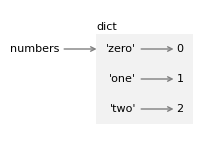

In [12]:
from diagram import diagram, adjust, Bbox

width, height, x, y = [1.83, 1.24, 0.49, 0.85]
ax = diagram(width, height)
bbox = binding1.draw(ax, x, y)
# adjust(x, y, bbox)

Un diccionario se representa con una caja con la palabra "dict" fuera y los elementos dentro.
Cada elemento se representa con una clave y una flecha que apunta a un valor.
Las comillas indican que las claves aquí son strings, no nombres de variables.

## Crear diccionarios

En la sección anterior creamos un diccionario vacío y añadimos elementos uno por uno usando el operador de corchetes.
En su lugar, podríamos haber creado el diccionario de una vez así.

In [13]:
numbers = {'zero': 0, 'one': 1, 'two': 2}

Cada elemento consiste en una clave y un valor separados por dos puntos.
Los elementos se separan con comas y se encierran entre llaves.

Otra forma de crear un diccionario es usar la función `dict`.
Podemos crear un diccionario vacío así.

In [14]:
empty = dict()
empty

{}

Y podemos hacer una copia de un diccionario así.

In [15]:
numbers_copy = dict(numbers)
numbers_copy

{'zero': 0, 'one': 1, 'two': 2}

A menudo es útil hacer una copia antes de realizar operaciones que modifican diccionarios.

## El operador in

El operador `in` también funciona con diccionarios; te dice si algo aparece como *clave* en el diccionario.

In [16]:
'one' in numbers

True

El operador `in` *no* comprueba si algo aparece como valor.

In [17]:
1 in numbers

False

Para ver si algo aparece como valor en un diccionario, puedes usar el método `values`, que devuelve una secuencia de valores, y luego usar el operador `in`.

In [18]:
1 in numbers.values()

True

Los elementos de un diccionario de Python se almacenan en una **hash table**, que es una forma de organizar datos con una propiedad notable: el operador `in` tarda aproximadamente la misma cantidad de tiempo sin importar cuántos elementos haya en el diccionario.
Eso hace posible escribir algunos algoritmos notablemente eficientes.

In [19]:
download('https://raw.githubusercontent.com/AllenDowney/ThinkPython/v3/words.txt');

Downloaded words.txt


Para demostrarlo, compararemos dos algoritmos para encontrar pares de palabras donde una es la inversa de la otra, como `stressed` y `desserts`.
Empezaremos leyendo la lista de palabras.

In [20]:
word_list = open('words.txt').read().split()
len(word_list)

113783

Y aquí está `reverse_word` del capítulo anterior.

In [21]:
def reverse_word(word):
    return ''.join(reversed(word))

La siguiente función recorre las palabras de la lista.
Para cada una, invierte las letras y luego comprueba si la palabra invertida está en la palabra lista.

In [22]:
def too_slow():
    count = 0
    for word in word_list:
        if reverse_word(word) in word_list:
            count += 1
    return count

Esta función tarda más de un minuto en ejecutarse.
El problema es que el operador `in` comprueba las palabras de la lista una por una, empezando por el principio.
Si no encuentra lo que busca, que ocurre la mayor parte del tiempo, tiene que buscar hasta el final.

Para medir cuánto tarda una función, podemos usar `%time`, que es uno de los "built-in magic commands" de Jupyter.
Estos comandos no forman parte del lenguaje Python, así que puede que no funcionen en otros entornos de desarrollo.

In [23]:
# %time too_slow()

Y el operador `in` está dentro del bucle, así que se ejecuta una vez por cada palabra.
Como hay más de 100 000 palabras en la lista, y para cada una comprobamos más de 100 000 palabras, el número total de comparaciones es el número de palabras al cuadrado -- aproximadamente --, que es casi 13 mil millones.

In [24]:
len(word_list)**2

12946571089

Podemos hacer que esta función sea mucho más rápida con un diccionario.
El siguiente bucle crea un diccionario que contiene las palabras como claves.

In [25]:
word_dict = {}
for word in word_list:
    word_dict[word] = 1

Los valores en `word_dict` son todos `1`, pero podrían ser cualquier cosa, porque nunca los vamos a buscar; solo usaremos este diccionario para comprobar si existe una clave.

Ahora aquí tienes una versión de la función anterior que reemplaza `word_list` por `word_dict`.

In [26]:
def much_faster():
    count = 0
    for word in word_dict:
        if reverse_word(word) in word_dict:
            count += 1
    return count

Esta función tarda menos de una centésima de segundo, así que es unas 10 000 veces más rápida que la versión anterior.

En general, el tiempo que se tarda en encontrar un elemento en una lista es proporcional a la longitud de la lista.
El tiempo que se tarda en encontrar una clave en un diccionario es casi constante, independientemente del número de elementos.

In [27]:
%time much_faster()

CPU times: user 94.1 ms, sys: 1.07 ms, total: 95.1 ms
Wall time: 94.7 ms


885

## Una colección de contadores

Supongamos que recibes un string y quieres contar cuántas veces aparece cada letra.
Un diccionario es una buena herramienta para este trabajo.
Empezaremos con un diccionario vacío.

In [28]:
counter = {}

Mientras recorremos las letras del string, supongamos que vemos la letra `'a'` por primera vez.
Podemos añadirla al diccionario así.

In [29]:
counter['a'] = 1

El valor `1` indica que hemos visto la letra una vez.
Más tarde, si volvemos a ver la misma letra, podemos incrementar el contador así.

In [30]:
counter['a'] += 1

Ahora el valor asociado con `'a'` es `2`, porque hemos visto la letra dos veces.

In [31]:
counter

{'a': 2}

La siguiente función usa estas características para contar el número de veces que aparece cada letra en un string.

In [32]:
def value_counts(string):
    counter = {}
    for letter in string:
        if letter not in counter:
            counter[letter] = 1
        else:
            counter[letter] += 1
    return counter

Cada vez que pasa por el bucle, si `letter` no está en el diccionario, creamos un nuevo elemento con clave `letter` y valor `1`.
Si `letter` ya está en el diccionario, incrementamos el valor asociado con `letter`.

Aquí tienes un ejemplo.

In [33]:
counter = value_counts('brontosaurus')
counter

{'b': 1, 'r': 2, 'o': 2, 'n': 1, 't': 1, 's': 2, 'a': 1, 'u': 2}

Los elementos de `counter` muestran que la letra `'b'` aparece una vez, `'r'` aparece dos veces, y así sucesivamente.

## Looping y diccionarios

Si usas un diccionario en una sentencia `for`, recorre las claves del diccionario.
Para demostrarlo, hagamos un diccionario que cuente las letras de `'banana'`.

In [34]:
counter = value_counts('banana')
counter

{'b': 1, 'a': 3, 'n': 2}

El siguiente bucle imprime las claves, que son las letras.

In [35]:
for key in counter:
    print(key)

b
a
n


Para imprimir los valores, podemos usar el método `values`.

In [36]:
for value in counter.values():
    print(value)

1
3
2


Para imprimir las claves y los valores, podemos recorrer las claves y buscar los valores correspondientes.

In [37]:
for key in counter:
    value = counter[key]
    print(key, value)

b 1
a 3
n 2


En el próximo capítulo, veremos una forma más concisa de hacer lo mismo.

## Listas y diccionarios

Puedes poner una lista en un diccionario como valor.
Por ejemplo, aquí tienes un diccionario que mapea el número `4` a una lista de cuatro letras.

In [38]:
d = {4: ['r', 'o', 'u', 's']}
d

{4: ['r', 'o', 'u', 's']}

Pero no puedes poner una lista en un diccionario como clave.
Esto es lo que ocurre si lo intentamos.

In [39]:
%%expect TypeError
letters = list('abcd')
d[letters] = 4

TypeError: unhashable type: 'list'

Mencioné antes que los diccionarios usan hash tables, y eso significa que las claves tienen que ser **hasheable**.

Un **hash** es una función que toma un valor (de cualquier tipo) y devuelve un entero.
Los diccionarios usan estos enteros, llamados hash valores, para almacenar y buscar claves.

Este sistema solo funciona si una clave es inmutable, de modo que su hash valor siempre sea el mismo.
Pero si una clave es mutable, su hash valor podría cambiar, y el diccionario no funcionaría.
Por eso las claves tienen que ser hasheables, y por eso tipos mutables como las listas no lo son.

Como los diccionarios son mutables, tampoco pueden usarse como claves.
Pero *sí* pueden usarse como valores.

## Acumular una lista

Para muchas tareas de programación, es útil recorrer una lista o diccionario mientras se construye otro.
Como ejemplo, recorreremos las palabras en `word_dict` y haremos una lista de palíndromos, es decir, palabras que se escriben igual hacia atrás y hacia adelante, como "noon" y "rotator".

En el capítulo anterior, uno de los ejercicios te pidió escribir una función que comprueba si una palabra es un palíndromo.
Aquí tienes una solución que usa `reverse_word`.

In [40]:
def is_palindrome(word):
    """Check if a word is a palindrome."""
    return reverse_word(word) == word

Si recorremos las palabras en `word_dict`, podemos contar el número de palíndromos así.

In [41]:
count = 0

for word in word_dict:
    if is_palindrome(word):
        count +=1

count

91

A estas alturas, este patrón resulta familiar.

* Antes del bucle, `count` se inicializa a `0`.

* Dentro del bucle, si `word` es un palíndromo, incrementamos `count`.

* Cuando termina el bucle, `count` contiene el número total de palíndromos.

Podemos usar un patrón similar para hacer una lista de palíndromos.

In [42]:
palindromes = []

for word in word_dict:
    if is_palindrome(word):
        palindromes.append(word)

palindromes[:10]

['aa', 'aba', 'aga', 'aha', 'ala', 'alula', 'ama', 'ana', 'anna', 'ava']

Así es como funciona:

* Antes del bucle, `palindromes` se inicializa con una lista vacía.

* Dentro del bucle, si `word` es un palíndromo, lo añadimos al final de `palindromes`.

* Cuando termina el bucle, `palindromes` es una lista de palíndromos.

En este bucle, `palindromes` se usa como **accumulator**, que es una variable que recoge o acumula datos durante una computación.

Ahora supongamos que queremos seleccionar solo palíndromos con siete o más letras.
Podemos recorrer `palindromes` y hacer una nueva lista que contenga solo palíndromos largos.

In [43]:
long_palindromes = []

for word in palindromes:
    if len(word) >= 7:
        long_palindromes.append(word)

long_palindromes

['deified', 'halalah', 'reifier', 'repaper', 'reviver', 'rotator', 'sememes']

Recorrer una lista así, seleccionando algunos elementos y omitiendo otros, se llama **filtrado**.

## Memos

Si ejecutaste la función `fibonacci` del [Capítulo 6](section_fibonacci), quizá notaste que cuanto mayor es el argumento que proporcionas, más tarda la función en ejecutarse.

In [44]:
def fibonacci(n):
    if n == 0:
        return 0

    if n == 1:
        return 1

    return fibonacci(n-1) + fibonacci(n-2)

Además, el tiempo de ejecución aumenta rápidamente.
Para entender por qué, considera la siguiente figura, que muestra el **call graph** de
`fibonacci` con `n=4`:

In [45]:
from diagram import make_binding, Frame, Arrow

bindings = [make_binding('n', i) for i in range(5)]
frames = [Frame([binding]) for binding in bindings]

In [46]:
arrowprops = dict(arrowstyle="-", color='gray', alpha=0.5, ls='-', lw=0.5)

def left_arrow(ax, bbox1, bbox2):
    x = bbox1.xmin + 0.1
    y = bbox1.ymin
    dx = bbox2.xmax - x - 0.1
    dy = bbox2.ymax - y
    arrow = Arrow(dx=dx, dy=dy, arrowprops=arrowprops)
    return arrow.draw(ax, x, y)

def right_arrow(ax, bbox1, bbox2):
    x = bbox1.xmax - 0.1
    y = bbox1.ymin
    dx = bbox2.xmin - x + 0.1
    dy = bbox2.ymax - y
    arrow = Arrow(dx=dx, dy=dy, arrowprops=arrowprops)
    return arrow.draw(ax, x, y)

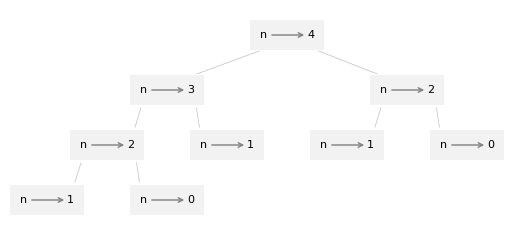

In [47]:
from diagram import diagram, adjust, Bbox

width, height, x, y = [4.94, 2.16, -1.03, 1.91]
ax = diagram(width, height)

dx = 0.6
dy = 0.55

bboxes = []
bboxes.append(frames[4].draw(ax, x+6*dx, y))

bboxes.append(frames[3].draw(ax, x+4*dx, y-dy))
bboxes.append(frames[2].draw(ax, x+8*dx, y-dy))

bboxes.append(frames[2].draw(ax, x+3*dx, y-2*dy))
bboxes.append(frames[1].draw(ax, x+5*dx, y-2*dy))
bboxes.append(frames[1].draw(ax, x+7*dx, y-2*dy))
bboxes.append(frames[0].draw(ax, x+9*dx, y-2*dy))

bboxes.append(frames[1].draw(ax, x+2*dx, y-3*dy))
bboxes.append(frames[0].draw(ax, x+4*dx, y-3*dy))

left_arrow(ax, bboxes[0], bboxes[1])
left_arrow(ax, bboxes[1], bboxes[3])
left_arrow(ax, bboxes[3], bboxes[7])
left_arrow(ax, bboxes[2], bboxes[5])

right_arrow(ax, bboxes[0], bboxes[2])
right_arrow(ax, bboxes[1], bboxes[4])
right_arrow(ax, bboxes[2], bboxes[6])
right_arrow(ax, bboxes[3], bboxes[8])

bbox = Bbox.union(bboxes)
# adjust(x, y, bbox)

Un call graph muestra un conjunto de función frames, con líneas que conectan cada frame con los frames de las funciones que llama.
En la parte superior del graph, `fibonacci` con `n=4` llama a `fibonacci` con ` n=3` y `n=2`.
A su vez, `fibonacci` con `n=3` llama a `fibonacci` con `n=2` y `n=1`. Y así sucesivamente.

Cuenta cuántas veces se llama a `fibonacci(0)` y `fibonacci(1)`.
Esta es una solución ineficiente al problema, y empeora a medida que el argumento crece.

Una solución es llevar un registro de los valores que ya se han calculado almacenándolos en un diccionario.
Un valor calculado previamente que se almacena para usarlo más tarde se llama **memo**.
Aquí tienes una versión "memoized" de `fibonacci`:

In [48]:
known = {0:0, 1:1}

def fibonacci_memo(n):
    if n in known:
        return known[n]

    res = fibonacci_memo(n-1) + fibonacci_memo(n-2)
    known[n] = res
    return res

`known` es un diccionario que lleva el registro de los números de Fibonacci que ya conocemos.
Empieza con dos elementos: `0` mapea a `0` y `1` mapea a `1`.

Cada vez que se llama a `fibonacci_memo`, comprueba `known`.
Si el resultado ya está ahí, puede devolverlo inmediatamente.
De lo contrario, tiene que calcular el nuevo valor, añadirlo al diccionario y devolverlo.

Comparando las dos funciones, `fibonacci(40)` tarda unos 30 segundos en ejecutarse.
`fibonacci_memo(40)` tarda unos 30 microsegundos, así que es un millón de veces más rápida.
En el notebook de este capítulo, verás de dónde vienen estas mediciones.

In [ ]:
# %time fibonacci(40)

In [ ]:
%time fibonacci_memo(40)

## Depuración

A medida que trabajas con datasets más grandes, puede volverse inmanejable depurar imprimiendo y comprobando la salida a mano. Aquí tienes algunas sugerencias para depurar datasets grandes:

1.  Reduce el tamaño de la entrada: Si es posible, reduce el tamaño del dataset. Por ejemplo, si el
    programa lee un archivo de texto, empieza solo con las primeras 10 líneas, o
    con el ejemplo más pequeño que puedas encontrar. Puedes editar los
    archivos directamente o, mejor, modificar el programa para que lea solo
    las primeras `n` líneas.

    Si hay un error, puedes reducir `n` al valor más pequeño donde ocurre el error.
    A medida que encuentres y corrijas errores, puedes aumentar `n` gradualmente.

2. Comprueba resúmenes y tipos: En lugar de imprimir y comprobar el dataset completo, considera
    imprimir resúmenes de los datos; por ejemplo, el número de elementos en
    un diccionario o el total de una lista de números.

    Una causa común de errores en tiempo de ejecución es un valor que no tiene el tipo correcto. Para depurar de este tipo de error, a menudo basta con imprimir el tipo de un valor.

3. Escribe autocomprobaciones: A veces puedes escribir código para comprobar errores automáticamente. Por
    ejemplo, si estás calculando la media de una lista de números, podrías
    comprobar que el resultado no sea mayor que el elemento más grande
    de la lista ni menor que el más pequeño. Esto se llama una "sanity
    check" porque detecta resultados que son "insane".

    Otro tipo de comprobación compara los resultados de dos computaciones diferentes para ver si son consistentes. Esto se llama una "consistency check".

4. Formatea la salida: Formatear la salida de depuración puede facilitar detectar un error. Vimos un ejemplo en [Capítulo 6](section_depuración_factorial). Otra herramienta que puede resultarte útil es el módulo `pprint`, que proporciona una función `pprint` que muestra tipos integrados en un formato más legible para humanos (`pprint` significa "pretty print").

    De nuevo, el tiempo que dediques a construir código de apoyo puede reducir el tiempo que dedicas a depurar.

## Glosario

**diccionario:**
 Un objeto que contiene pares clave-valor, también llamados elementos.

**elemento:**
 En un diccionario, otro nombre para un par clave-valor.

**clave:**
 Un objeto que aparece en un diccionario como la primera parte de un par clave-valor.

**valor:**
 Un objeto que aparece en un diccionario como la segunda parte de un par clave-valor. Esto es más específico que nuestro uso anterior de la palabra "valor".

**mapeo:**
  Una relación en la que cada elemento de un conjunto corresponde a un elemento de otro conjunto.

**hash table:**
Una colección de pares clave-valor organizada para que podamos buscar una clave y encontrar su valor de forma eficiente.

**hasheable:**
Tipos inmutables como enteros, floats y strings son hasheable.
Tipos mutables como listas y diccionarios no lo son.

**función hash:**
Una función que toma un objeto y calcula un entero que se usa para localizar una clave en una hash table.

**accumulator:**
 Una variable usada en un bucle para sumar o acumular un resultado.

**filtrado:**
Recorrer una secuencia y seleccionar u omitir elementos.

**call graph:**
Un diagrama que muestra cada frame creado durante la ejecución de un programa, con una flecha desde cada código que llama hacia cada callee.

**memo:**
 Un valor calculado almacenado para evitar computación futura innecesaria.

## Ejercicios

In [49]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

Exception reporting mode: Verbose


### Pregunta a un asistente virtual

En este capítulo, dije que las claves de un diccionario tienen que ser hasheabless y di una explicación breve. Si quieres más detalles, pregunta a un asistente virtual: "¿Por qué las claves de los diccionarios de Python tienen que ser hasheabless?"

En [una sección anterior](section_dictionary_in_operator), almacenamos una lista de palabras como claves en un diccionario para poder usar una versión eficiente del operador `in`.
Podríamos haber hecho lo mismo usando un `set`, que es otro tipo de dato integrado.
Pregunta a un asistente virtual: "How do I make a Python set from a lista of strings and check whether a string is an elemento of the set?"

### Ejercicio

Los diccionarios tienen un método llamado `get` que toma una clave y un valor por defecto.
Si la clave aparece en el diccionario, `get` devuelve el valor correspondiente; de lo contrario devuelve el valor por defecto.
Por ejemplo, aquí tienes un diccionario que mapea las letras de un string al número de veces que aparecen.

In [50]:
counter = value_counts('brontosaurus')

Si buscamos una letra que aparece en la palabra, `get` devuelve el número de veces que aparece.

In [51]:
counter.get('b', 0)

1

Si buscamos una letra que no aparece, obtenemos el valor por defecto, `0`.

In [52]:
counter.get('c', 0)

0

Usa `get` para escribir una versión más concisa de `value_counts`.
Deberías poder eliminar la sentencia `if`.

In [53]:
def value_counts(string):
    counter = {}
    for letter in string:
        counter[letter] = counter.get(letter, 0) + 1
    return counter

In [54]:
print(value_counts("brontosaurus"))

{'b': 1, 'r': 2, 'o': 2, 'n': 1, 't': 1, 's': 2, 'a': 1, 'u': 2}


### Ejercicio

¿Cuál es la palabra más larga que se te ocurre donde cada letra aparece solo una vez?
Veamos si podemos encontrar una más larga que `unpredictably`.

Escribe una función llamada `has_duplicates` que tome una secuencia, como una lista o string, como parameter y devuelva `True` si hay algún elemento que aparece en la secuencia más de una vez.

Para empezar, aquí tienes un esquema de la función con doctests.

In [55]:
def has_duplicates(secuencia):
    """Check whether any element in a sequence appears more than once.

    >>> has_duplicates('banana')
    True
    >>> has_duplicates('ambidextrously')
    False
    >>> has_duplicates([1, 2, 2])
    True
    >>> has_duplicates([1, 2, 3])
    False
    """
    vistos = {}
    for elemento in secuencia:
        if elemento in vistos:
           return True
        vistos[elemento] = 1

    return False

In [56]:
# Solution goes here
has_duplicates('banana')

True

In [57]:
has_duplicates('ambidextrously')

False

In [59]:
has_duplicates([1, 2, 2])

True

In [60]:
has_duplicates([1, 2, 3])

False

Puedes usar `doctest` para probar tu función.

In [61]:
from doctest import run_docstring_examples

def run_doctests(func):
    run_docstring_examples(func, globals(), name=func.__name__)

run_doctests(has_duplicates)

Puedes usar este bucle para encontrar las palabras más largas sin letras repetidas.

In [62]:
no_repeats = []

for word in word_list:
    if len(word) > 12 and not has_duplicates(word):
        no_repeats.append(word)

no_repeats

['ambidextrously',
 'lycanthropies',
 'metalworkings',
 'multibranched',
 'unpredictably']

### Ejercicio

Escribe una función llamada `find_repeats` que tome un diccionario que mapea cada clave a un contador, como el resultado de `value_counts`.
Debe recorrer el diccionario y devolver una lista de claves que tengan recuentos mayores que `1`.
Puedes usar el siguiente esquema para empezar.

In [63]:
def find_repeats(counter):
    """Makes a list of keys with values greater than 1.

    counter: dictionary that maps from keys to counts

    returns: list of keys
    """
    repeats = []
    for key in counter:
        if counter[key]>1:
           repeats.append(key)

    return repeats

In [67]:
# Solution goes here
counter = value_counts([1, 2, 3, 2, 1])
print(find_repeats(counter))

[1, 2]


In [68]:
counter = value_counts('banana')
print(find_repeats(counter))

['a', 'n']


Puedes usar los siguientes ejemplos para probar tu código.
Primero, haremos un diccionario que mapea letras a recuentos.

In [64]:
counter1 = value_counts('banana')
counter1

{'b': 1, 'a': 3, 'n': 2}

El resultado de `find_repeats` debería ser `['a', 'n']`.

In [65]:
repeats = find_repeats(counter1)
repeats

['a', 'n']

Aquí tienes otro ejemplo que empieza con una lista de números.
El resultado debería ser `[1, 2]`.

In [66]:
counter1 = value_counts([1, 2, 3, 2, 1])
repeats = find_repeats(counter1)
repeats

[1, 2]

### Ejercicio

Supongamos que ejecutas `value_counts` con dos palabras diferentes y guardas los resultados en dos diccionarios.

In [ ]:
counter1 = value_counts('brontosaurus')
counter2 = value_counts('apatosaurus')

Cada diccionario mapea un conjunto de letras al número de veces que aparecen.
Escribe una función llamada `add_counters` que tome dos diccionarios como estos y devuelva un nuevo diccionario que contenga todas las letras y el número total de veces que aparecen en cualquiera de las dos palabras.

Hay muchas formas de resolver este problema.
Cuando tengas una solución que funcione, considera pedir a un asistente virtual soluciones diferentes.

In [69]:
# Solution goes here
def add_counters (counter1, counter2):
    result = {}
    for key in counter1:
        result[key] = counter1[key]
    for key in counter2:
        if key in result:
           result[key] = result[key] + counter2[key]
        else:
           result[key] = counter2[key]
    return result

In [73]:
counter1 = {'a': 2, 'b': 1}
counter2 = {'a': 3, 'c': 1}

resultado = add_counters(counter1, counter2)
print(resultado)

{'a': 5, 'b': 1, 'c': 1}


In [75]:
# Solution goes here - solution with IA using get
def add_counters(counter1, counter2):
    result = {}

    for key in counter1:
        result[key] = counter1[key]

    for key in counter2:
        result[key] = result.get(key, 0) + counter2[key]

    return result

In [76]:
counter1 = {'a': 2, 'b': 1}
counter2 = {'a': 3, 'c': 1}

resultado = add_counters(counter1, counter2)
print(resultado)

{'a': 5, 'b': 1, 'c': 1}


### Ejercicio

Una palabra es "interlocking" si podemos dividirla en dos palabras tomando letras alternas.
Por ejemplo, "schooled" es una palabra interlocking porque puede dividirse en "shoe" y "cold".

Para seleccionar letras alternas de un string, puedes usar un operador de porción con tres componentes que indican dónde empezar, dónde detenerse y el "step size" entre las letras.

En el siguiente porción, el primer componente es `0`, así que empezamos con la primera letra.
El segundo componente es `None`, lo que significa que debemos llegar hasta el final del string.
Y el tercer componente es `2`, así que hay dos pasos entre las letras que seleccionamos.

In [77]:
word = 'schooled'
first = word[0:None:2]
first

'shoe'

En lugar de proporcionar `None` como segundo componente, podemos obtener el mismo efecto omitiéndolo por completo.
Por ejemplo, el siguiente porción selecciona letras alternas, empezando por la segunda letra.

In [79]:
second = word[1::2]
second

'cold'

Escribe una función llamada `is_interlocking` que tome una palabra como argumento y devuelva `True` si puede dividirse en dos palabras interlocking.

In [80]:
# Solution goes here
def is_interlocking(word):
    first = word[0::2]
    second = word[1::2]

    return first in word_dict and second in word_dict

In [82]:
print(is_interlocking('schooled'))

True


In [83]:
print(is_interlocking('banana'))

False


Puedes usar el siguiente bucle para encontrar las palabras interlocking en la palabra lista.

In [81]:
for word in word_list:
    if len(word) >= 8 and is_interlocking(word):
        first = word[0::2]
        second = word[1::2]
        print(word, first, second)

adroitly aril doty
agrarians arras gain
alienees aine lees
arrestee arse rete
arrestees arses rete
ballooned blond aloe
barmaids brad amis
baudrons burn ados
beakless bals ekes
beamless bals emes
bloodred bode lord
blueness buns lees
booklets bolt okes
burseeds bred uses
calliope clip aloe
calliopes clips aloe
cellules clue ells
cheerier cere heir
colludes clue olds
cookless cols okes
coolness cons oles
countess cuts ones
couplets cult opes
dainties dite anis
doorless dols ores
dourness duns ores
fairness fins ares
fleetest fets leet
fleetness fetes lens
foulness funs oles
freeness fens rees
friended fine redd
furrings frig urns
goalless gals oles
greeniest genet reis
greyness gens ryes
grounded gone rudd
hooklets holt okes
ignitron into girn
isleless ills sees
mailless mils ales
moonless mols ones
moonlets molt ones
moonsets most ones
neutrals nurl etas
oghamist ohms gait
parietes pree aits
peakless pals ekes
plainness panes lins
playless pals lyes
pleonasm pens loam
poorness pons ore

[Think Python: 3rd Edition](https://allendowney.github.io/ThinkPython/index.html)

Copyright 2024 [Allen B. Downey](https://allendowney.com)

Traducción al español por midudev (Miguel Ángel Durán).

Código license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)